# Bees production 

### Setup

In [14]:
import pandas as pd 
import utils
import matplotlib.pyplot as plt
import importlib
importlib.reload(utils)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


honey_production_df, apistox_df, bees_health_weather_dict = utils.load_bees_datasets()

 honey_production_df (1115, 9) : Done! 

 apistox_df (1035, 13) : Done! 

 Apiary_Information.csv (13, 4) : Done!
 HCC_Inspections.csv (2404, 11) : Done!
 Hive_Information.csv (188, 3) : Done!
 Hourly_Weather.csv (3672, 15) : Done!
 Weather_Observations.csv (1776, 4) : Done!
 Weather_Stations.csv (3, 3) : Done!

Datasets collection completed.


## Part 1: Honey production 

In [15]:
n_states = honey_production_df.state.nunique()
utils.EDA(honey_production_df, head = n_states) #44 states
honey_production_df.drop(columns=["Unnamed: 0"], inplace=True)
honey_production_df_copy = honey_production_df.copy()

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


##-------------- DESCRIBE --------------------------##
        Unnamed: 0  colonies_number  yield_per_colony    production  \
count  1115.00000      1115.000000       1115.000000  1.115000e+03   
mean    557.00000     62438

### Production Analysis 

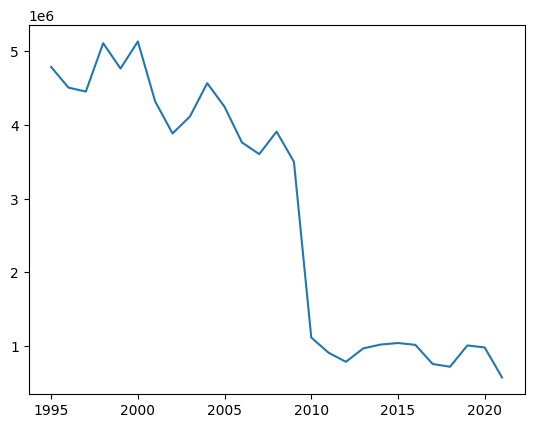

In [16]:
honey_production_df = honey_production_df_copy.copy()

# import numpy as np
# state_group = []
# for state in honey_production_df.state.unique():
#     state_production = honey_production_df[honey_production_df.state == state]
#     #filtering for the states that have data for all the 27 years from 1995 to 2021
#     if len(state_production) < 27:
#         honey_production_df.drop(state_production.index, inplace=True)
#     else:
#         figure = plt.figure(figsize =(15,5))
#         plot1 = figure.add_subplot(1, 2, 1)
#         plot1.plot(state_production.year, state_production.yield_per_colony, marker = ".")
#         plot1.set_title(str(state) + "'s yield per colony")
#         plot2 = figure.add_subplot(1, 2, 2)
#         plot2.plot(state_production.year, state_production.production, marker = ".")
#         #plt.plot(state_production.year, state_production.yield_per_colony, marker = ".")
#         plt.title(str(state) + "'s production")
#         plt.show()
        #plot = figure.add_subplot(int(np.sqrt(n_states)) +1, int(np.sqrt(n_states)) )


plt.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["production"].mean())

### Production Trend Prediction

0.7466346015309436


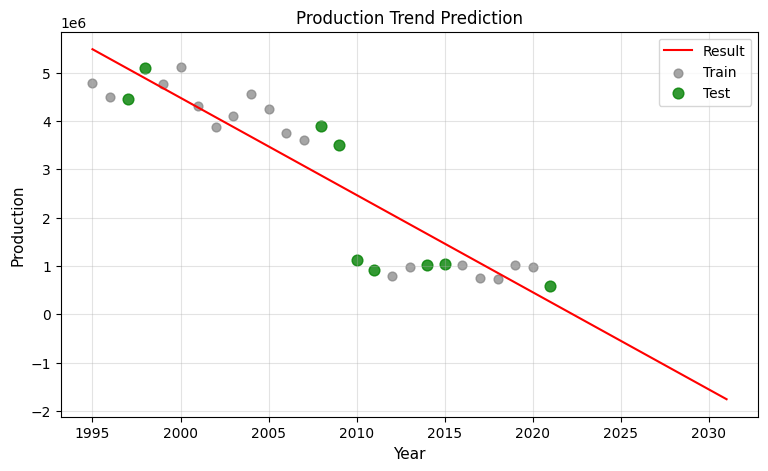

In [147]:
#setting up data
import numpy as np
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means.values, 
                                                    test_size=0.3,
                                                    random_state=40)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Result")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()


### Price analysis

## Part 2: Apistox 

## Part 3: Weather Effects on Bees Health
